<a href="https://colab.research.google.com/github/rafaelrochaplay/geomodelagem/blob/main/UENF_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install cdsapi
%pip install netcdf4

In [ ]:
import cdsapi

dataset = "reanalysis-era5-single-levels"
request = {
    "product_type": ["reanalysis"],
    "variable": ["2m_temperature"],
    "year": ["2023"],
    "month": ["05"],
    "day": ["30"],
    "time": ["03:00"],
    "data_format": "netcdf",
    "download_format": "unarchived"
}

client = cdsapi.Client(url= 'https://cds.climate.copernicus.eu/api',
key = '2f04daa0-b275-4933-aa09-b774ee8da9d9')
client.retrieve(dataset, request).download()

2026-06-30 16:39:07,229 INFO Request ID is 5fff2268-9b11-4d31-af28-5f31096ffcf6
INFO:ecmwf.datastores.legacy_client:Request ID is 5fff2268-9b11-4d31-af28-5f31096ffcf6
2026-06-30 16:39:07,399 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-06-30 16:39:32,166 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


4b661d323fa39d2931f3b1f679288b00.nc:   0%|          | 0.00/1.46M [00:00<?, ?B/s]

'4b661d323fa39d2931f3b1f679288b00.nc'

In [ ]:
# Colab only
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import xarray as xr
import pandas as pd

ds = xr.open_dataset('4b661d323fa39d2931f3b1f679288b00.nc', engine = 'h5netcdf')

df_converted = ds.to_dataframe()

print('Dataset converted to DataFrame and saved to output_data_irradiance.csv')

Dataset converted to DataFrame and saved to output_data_irradiance.csv


In [ ]:
df_converted

t2m  number expver
valid_time          latitude longitude                           
2023-05-30 03:00:00  90.0    0.00       270.332947       0   0001
                             0.25       270.332947       0   0001
                             0.50       270.332947       0   0001
                             0.75       270.332947       0   0001
                             1.00       270.332947       0   0001
...                                            ...     ...    ...
                    -90.0    358.75     223.450134       0   0001
                             359.00     223.450134       0   0001
                             359.25     223.450134       0   0001
                             359.50     223.450134       0   0001
                             359.75     223.450134       0   0001

[1038240 rows x 3 columns]

In [ ]:
def dms_to_decimal(degrees, minutes, seconds, direction):
    decimal = float(degrees) + float(minutes)/60 + float(seconds)/3600
    if direction in ['S', 'W']:
        decimal *= -1
    return decimal

# User provided coordinates for Pará
lat_dms = (1, 58, 30.0, 'S') # 1°58'30.0"S
lon_dms = (48, 57, 36.0, 'W') # 48°57'36.0"W

# Convert to decimal degrees
target_lat = dms_to_decimal(*lat_dms)
target_lon = dms_to_decimal(*lon_dms)

print(f"Target Latitude (decimal): {target_lat}")
print(f"Target Longitude (decimal): {target_lon}")

Target Latitude (decimal): -1.975
Target Longitude (decimal): -48.96


In [ ]:
# The 'valid_time' index is not relevant for spatial lookup, so we need to reset the index
df_reset = df_converted.reset_index()

# Find the nearest data point
# Calculate the absolute difference for latitude and longitude
df_reset['lat_diff'] = abs(df_reset['latitude'] - target_lat)
df_reset['lon_diff'] = abs(df_reset['longitude'] - target_lon)

# Find the row with the minimum sum of differences
# A more robust approach might use haversine distance for geographical proximity
# but for simplicity and grid data, min diff in lat/lon is often sufficient
nearest_idx = (df_reset['lat_diff'] + df_reset['lon_diff']).idxmin()

nearest_data = df_reset.loc[nearest_idx]

# Extract the 2m temperature (t2m) and convert from Kelvin to Celsius
temperature_kelvin = nearest_data['t2m']
temperature_celsius = temperature_kelvin - 273.15

print(f"Data point closest to ({target_lat:.4f}, {target_lon:.4f}):")
print(f"  Latitude: {nearest_data['latitude']:.2f}")
print(f"  Longitude: {nearest_data['longitude']:.2f}")
print(f"  Temperature (2m): {temperature_celsius:.2f} °C ({temperature_kelvin:.2f} K)")
print(f"  Valid Time: {nearest_data['valid_time']}")

NameError: name 'df_converted' is not defined

In [ ]:
!pip install cdsapi
import cdsapi
import xarray as xr
import pandas as pd

# Redownload the NetCDF file
dataset = "reanalysis-era5-single-levels"
request = {
    "product_type": ["reanalysis"],
    "variable": ["2m_temperature"],
    "year": ["2023"],
    "month": ["05"],
    "day": ["30"],
    "time": ["03:00"],
    "data_format": "netcdf",
    "download_format": "unarchived"
}

client = cdsapi.Client(url= 'https://cds.climate.copernicus.eu/api',
key = '2f04daa0-b275-4933-aa09-b774ee8da9d9')
client.retrieve(dataset, request).download()

# Re-open the NetCDF file to ensure df_converted is available
ds = xr.open_dataset('4b661d323fa39d2931f3b1f679288b00.nc', engine = 'h5netcdf')
df_converted = ds.to_dataframe()

# The 'valid_time' index is not relevant for spatial lookup, so we need to reset the index
df_reset = df_converted.reset_index()

# Find the nearest data point
# Calculate the absolute difference for latitude and longitude
df_reset['lat_diff'] = abs(df_reset['latitude'] - target_lat)
# Convert target_lon to 0-360 range for comparison with dataset's longitude
target_lon_360_for_df = target_lon % 360
df_reset['lon_diff'] = abs(df_reset['longitude'] - target_lon_360_for_df)

# Find the row with the minimum sum of differences
# A more robust approach might use haversine distance for geographical proximity
# but for simplicity and grid data, min diff in lat/lon is often sufficient
nearest_idx = (df_reset['lat_diff'] + df_reset['lon_diff']).idxmin()

nearest_data = df_reset.loc[nearest_idx]

# Extract the 2m temperature (t2m) and convert from Kelvin to Celsius
temperature_kelvin = nearest_data['t2m']
temperature_celsius = temperature_kelvin - 273.15

print(f"Data point closest to ({target_lat:.4f}, {target_lon:.4f}):")
print(f"  Latitude: {nearest_data['latitude']:.2f}")
print(f"  Longitude: {nearest_data['longitude']:.2f}")
print(f"  Temperature (2m): {temperature_celsius:.2f} °C ({temperature_kelvin:.2f} K)")
print(f"  Valid Time: {nearest_data['valid_time']}")

2026-07-01 17:04:51,082 INFO Request ID is 5859510a-b270-4559-bd9c-7373e54b49dd
INFO:ecmwf.datastores.legacy_client:Request ID is 5859510a-b270-4559-bd9c-7373e54b49dd
2026-07-01 17:04:51,261 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-07-01 17:05:13,105 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


4b661d323fa39d2931f3b1f679288b00.nc:   0%|          | 0.00/1.46M [00:00<?, ?B/s]

Data point closest to (-1.9750, -48.9600):
  Latitude: -2.00
  Longitude: 311.00
  Temperature (2m): 25.54 °C (298.69 K)
  Valid Time: 2023-05-30 03:00:00


Dados selecionados: (16, 16) pontos encontrados.


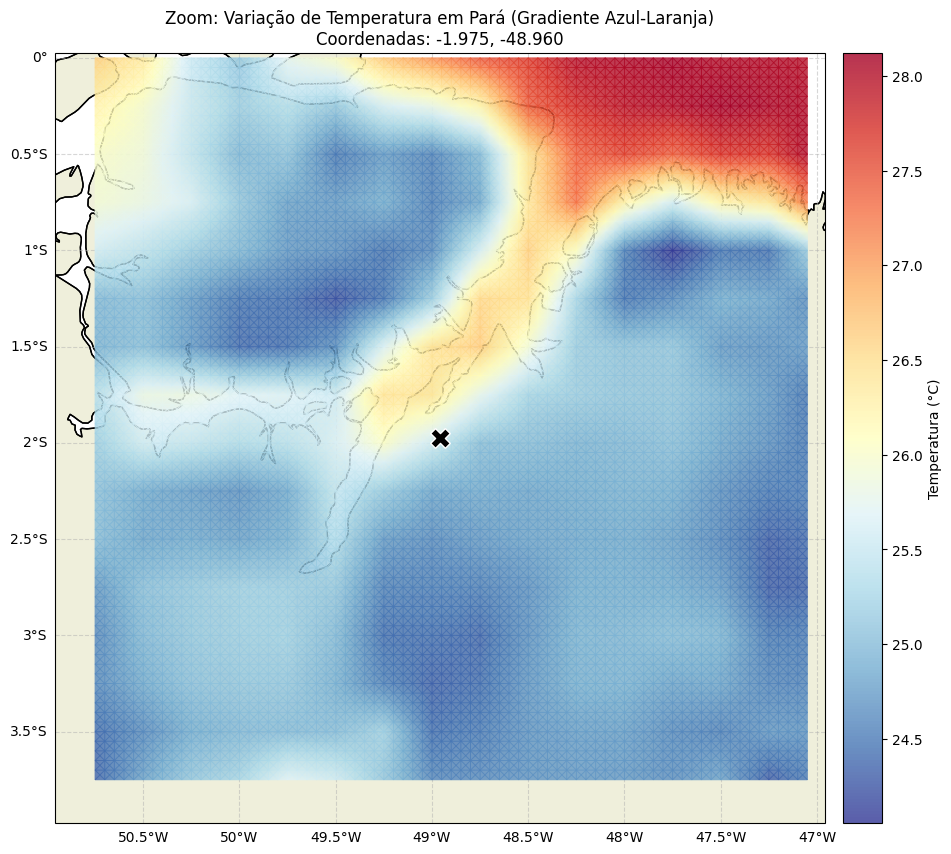

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import pandas as pd
import numpy as np
import xarray as xr

# 1. Select the 2m temperature data
temp_data = ds['t2m'].isel(valid_time=0)

# 2. Define zoom boundaries
zoom_buffer = 2.0
zoom_min_lon, zoom_max_lon = target_lon - zoom_buffer, target_lon + zoom_buffer
zoom_min_lat, zoom_max_lat = target_lat - zoom_buffer, target_lat + zoom_buffer

# 3. Convert longitudes to 0-360 range
zoom_min_lon_360 = zoom_min_lon % 360
zoom_max_lon_360 = zoom_max_lon % 360

# 4. Handle descending Latitude (ERA5 is usually 90 to -90)
lat_start = max(zoom_min_lat, zoom_max_lat)
lat_end = min(zoom_min_lat, zoom_max_lat)

temp_data_zoomed = temp_data.sel(
    latitude=slice(lat_start, lat_end),
    longitude=slice(zoom_min_lon_360, zoom_max_lon_360)
)

temp_celsius_zoomed = temp_data_zoomed - 273.15

if temp_celsius_zoomed.size == 0:
    print(f"Aviso: Nenhum dado encontrado. Lat: {lat_start:.2f} to {lat_end:.2f}, Lon: {zoom_min_lon_360:.2f} to {zoom_max_lon_360:.2f}")
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([zoom_min_lon, zoom_max_lon, zoom_min_lat, zoom_max_lat])
    ax.set_title("Sem dados para a região selecionada")
    plt.show()
else:
    print(f"Dados selecionados: {temp_celsius_zoomed.shape} pontos encontrados.")

    # 5. Interpolation
    fine_res = 0.05
    new_lats = np.arange(temp_celsius_zoomed.latitude.min(), temp_celsius_zoomed.latitude.max() + fine_res, fine_res)
    new_lons = np.arange(temp_celsius_zoomed.longitude.min(), temp_celsius_zoomed.longitude.max() + fine_res, fine_res)

    temp_interp = temp_celsius_zoomed.interp(latitude=new_lats, longitude=new_lons, method='linear')

    # 6. Plotting
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.set_extent([zoom_min_lon, zoom_max_lon, zoom_min_lat, zoom_max_lat], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, edgecolor='black', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=1, zorder=2)
    ax.add_feature(cfeature.BORDERS, linestyle=':', zorder=2)

    # Convert lons for plotting
    plot_lons = temp_interp.longitude.values
    plot_lons[plot_lons > 180] -= 360

    # Updated colormap to 'RdYlBu_r' for a blue-to-orange/red gradient
    mesh = ax.pcolormesh(plot_lons, temp_interp.latitude, temp_interp.values,
                         cmap='RdYlBu_r', shading='gouraud', alpha=0.8, zorder=3, transform=ccrs.PlateCarree())

    plt.colorbar(mesh, ax=ax, label='Temperatura (°C)', pad=0.02)

    # Using black for the marker for better visibility on the new palette
    ax.scatter(target_lon, target_lat, color='black', marker='X', s=200, edgecolor='white', zorder=5, transform=ccrs.PlateCarree())

    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = gl.right_labels = False

    plt.title(f"Zoom: Variação de Temperatura em Pará (Gradiente Azul-Laranja)\nCoordenadas: {target_lat:.3f}, {target_lon:.3f}")
    plt.show()

In [ ]:
import cdsapi

dataset = "reanalysis-era5-single-levels"
request = {
    "product_type": ["reanalysis"],
    "variable": [
        "2m_temperature",
        "total_precipitation",
        "clear_sky_direct_solar_radiation_at_surface",
        "evaporation"
    ],
    "year": ["2025"],
    "month": ["05"],
    "day": ["03"],
    "time": ["12:00"],
    "data_format": "netcdf",
    "download_format": "unarchived"
}

client = cdsapi.Client(url= 'https://cds.climate.copernicus.eu/api',
key = '2f04daa0-b275-4933-aa09-b774ee8da9d9')
client.retrieve(dataset, request).download()


2026-06-30 17:58:29,925 INFO Request ID is 84a994b1-f282-46d8-9048-8f122e905c16
INFO:ecmwf.datastores.legacy_client:Request ID is 84a994b1-f282-46d8-9048-8f122e905c16
2026-06-30 17:58:30,070 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-06-30 17:58:43,944 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-06-30 17:58:51,667 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


45f5295820dccf53cb382bd166fa7f65.zip:   0%|          | 0.00/4.80M [00:00<?, ?B/s]

'45f5295820dccf53cb382bd166fa7f65.zip'

In [ ]:
import xarray as xr
import pandas as pd

# Open the NetCDF file that was extracted from the downloaded zip file
ds2 = xr.open_dataset('/content/unzipped_folder/data_stream-oper_stepType-accum.nc', engine = 'h5netcdf')
ds3 = xr.open_dataset('/content/unzipped_folder/data_stream-oper_stepType-instant.nc', engine = 'h5netcdf')

df_converted2 = ds2.to_dataframe()
df_converted3 = ds3.to_dataframe()
df_combined = pd.concat([df_converted2, df_converted3], axis=1)

df_combined.to_csv('dados.csv', index = True)

print('Dataset converted to DataFrame and saved to dados.csv')

Dataset converted to DataFrame and saved to dados.csv


/usr/local/lib/python3.12/dist-packages/cartopy/mpl/geoaxes.py:1890: UserWarning: Handling wrapped coordinates with gouraud shading is likely to introduce artifacts. It is recommended to remove the wrap manually before calling pcolormesh.
  warnings.warn("Handling wrapped coordinates with gouraud "


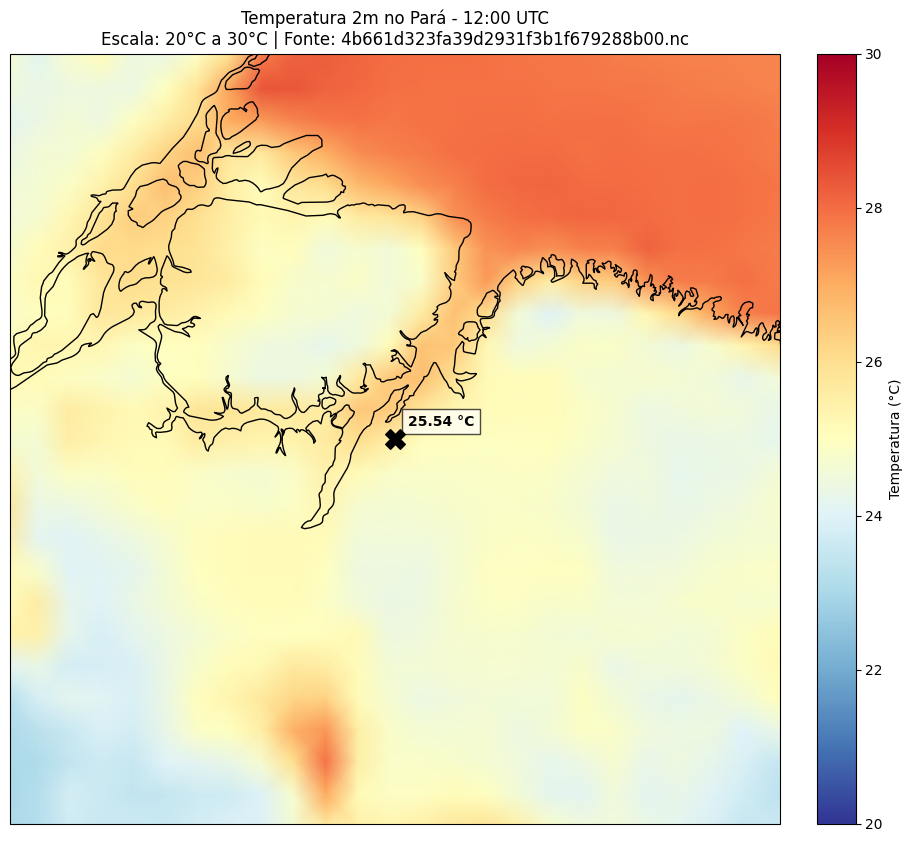

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import os

# Localizações potenciais para arquivos .nc
search_paths = ['/content/', '/content/era5_data_extraction/', '/content/unzipped_folder/']
all_nc_files = []

for path in search_paths:
    if os.path.exists(path):
        for root, dirs, files in os.walk(path):
            for f in files:
                if f.endswith('.nc'):
                    all_nc_files.append(os.path.join(root, f))

try:
    ds_t2m = None
    found_file = ""
    for fpath in all_nc_files:
        try:
            ds = xr.open_dataset(fpath, engine='h5netcdf')
            if 't2m' in ds.variables:
                ds_t2m = ds
                found_file = fpath
                break
        except:
            continue

    if ds_t2m is not None:
        # Selecionar dados para 12:00 UTC
        temp_12h_data = ds_t2m['t2m'].sel(valid_time='2025-05-03T12:00:00', method='nearest')

        target_lat = -1.975
        target_lon = -48.96
        target_lon_360 = target_lon % 360

        # Inicializar o Mapa
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

        zoom_buffer = 3.0
        ax.set_extent([target_lon - zoom_buffer, target_lon + zoom_buffer,
                       target_lat - zoom_buffer, target_lat + zoom_buffer])

        ax.add_feature(cfeature.LAND, facecolor='#f9f9f9')
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.BORDERS, linestyle=':')

        # Preparar coordenadas e dados
        lons = temp_12h_data.longitude.values
        lats = temp_12h_data.latitude.values
        lons_plot = np.where(lons > 180, lons - 360, lons)
        temp_c = temp_12h_data.values - 273.15

        # Plotar com gradiente azul-laranja (RdYlBu_r) e limites ajustados (20-30°C)
        im = ax.pcolormesh(lons_plot, lats, temp_c, cmap='RdYlBu_r',
                           shading='gouraud', transform=ccrs.PlateCarree(),
                           vmin=20, vmax=30)

        plt.colorbar(im, label='Temperatura (°C)', fraction=0.046, pad=0.04)

        # Adicionar marcador e valor específico
        point_val = temp_12h_data.sel(latitude=target_lat, longitude=target_lon_360, method='nearest').item() - 273.15
        ax.scatter(target_lon, target_lat, color='black', marker='X', s=200, transform=ccrs.PlateCarree(), zorder=5)
        ax.text(target_lon + 0.1, target_lat + 0.1, f'{point_val:.2f} °C',
                transform=ccrs.PlateCarree(), fontweight='bold', bbox=dict(facecolor='white', alpha=0.7))

        plt.title(f'Temperatura 2m no Pará - 12:00 UTC\nEscala: 20°C a 30°C | Fonte: {os.path.basename(found_file)}')
        plt.show()
    else:
        print('Não foi possível encontrar um arquivo NetCDF com a variável "t2m".')
except Exception as e:
    print(f'Ocorreu um erro: {e}')

/usr/local/lib/python3.12/dist-packages/cartopy/mpl/geoaxes.py:1890: UserWarning: Handling wrapped coordinates with gouraud shading is likely to introduce artifacts. It is recommended to remove the wrap manually before calling pcolormesh.
  warnings.warn("Handling wrapped coordinates with gouraud "
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_rivers_lake_centerlines.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


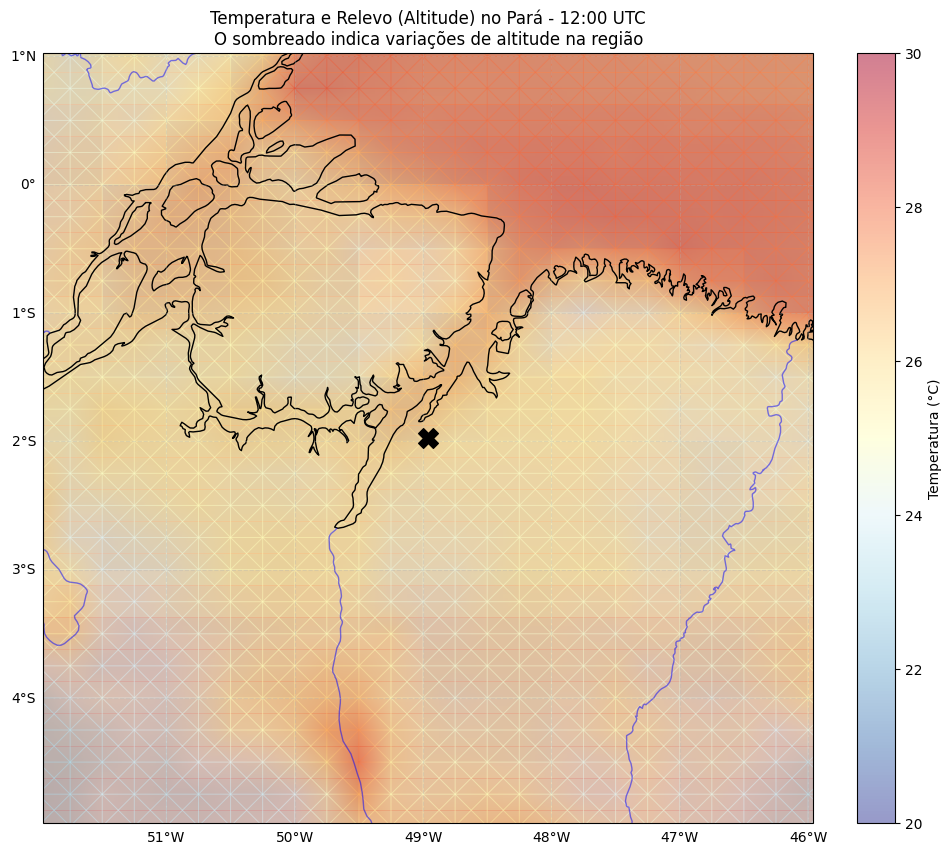

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import os

# Vamos utilizar o relevo sombreado do Natural Earth para representar a altitude
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Definir a extensão baseada na localização anterior
zoom_buffer = 3.0
ax.set_extent([target_lon - zoom_buffer, target_lon + zoom_buffer,
               target_lat - zoom_buffer, target_lat + zoom_buffer])

# Adicionar Relevo Sombreado (Hillshade) para representar altitude
# O 'shaded_relief' do Natural Earth é uma ótima forma de visualizar topografia
ax.stock_img()

# Adicionar feições geográficas
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.7)
ax.add_feature(cfeature.RIVERS, edgecolor='blue', alpha=0.5)

# Plotar os dados de temperatura por cima com transparência (alpha)
# Isso permite ver o relevo por baixo das cores de temperatura
lons = temp_12h_data.longitude.values
lats = temp_12h_data.latitude.values
lons_plot = np.where(lons > 180, lons - 360, lons)
temp_c = temp_12h_data.values - 273.15

im = ax.pcolormesh(lons_plot, lats, temp_c, cmap='RdYlBu_r',
                   shading='gouraud', transform=ccrs.PlateCarree(),
                   vmin=20, vmax=30, alpha=0.5) # Alpha reduzido para ver o relevo

plt.colorbar(im, label='Temperatura (°C)', fraction=0.046, pad=0.04)

# Marcador da localização
ax.scatter(target_lon, target_lat, color='black', marker='X', s=200,
           transform=ccrs.PlateCarree(), zorder=5)

# Título explicativo
plt.title(f'Temperatura e Relevo (Altitude) no Pará - 12:00 UTC\nO sombreado indica variações de altitude na região')

gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.3)
gl.top_labels = gl.right_labels = False

plt.show()

In [ ]:
df_converted2

tp      cdir             e  \
valid_time          latitude longitude                                     
2025-05-03 12:00:00  90.0    0.00       0.000015  646976.0 -7.274561e-06   
                             0.25       0.000015  646976.0 -7.274561e-06   
                             0.50       0.000015  646976.0 -7.274561e-06   
                             0.75       0.000015  646976.0 -7.274561e-06   
                             1.00       0.000015  646976.0 -7.274561e-06   
...                                          ...       ...           ...   
                    -90.0    358.75     0.000003       0.0  1.462176e-07   
                             359.00     0.000003       0.0  1.462176e-07   
                             359.25     0.000003       0.0  1.462176e-07   
                             359.50     0.000003       0.0  1.462176e-07   
                             359.75     0.000003       0.0  1.462176e-07   

                                        number expver  
valid_time          latitude longitude                 
2025-05-03 12:00:00  90.0    0.00            0   0001  
                             0.25            0   0001  
                             0.50            0   0001  
                             0.75            0   0001  
                             1.00            0   0001  
...                                        ...    ...  
                    -90.0    358.75          0   0001  
                             359.00          0   0001  
                             359.25          0   0001  
                             359.50          0   0001  
                             359.75          0   0001  

[1038240 rows x 5 columns]

In [ ]:
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 73.3 MB/s eta 0:00:00


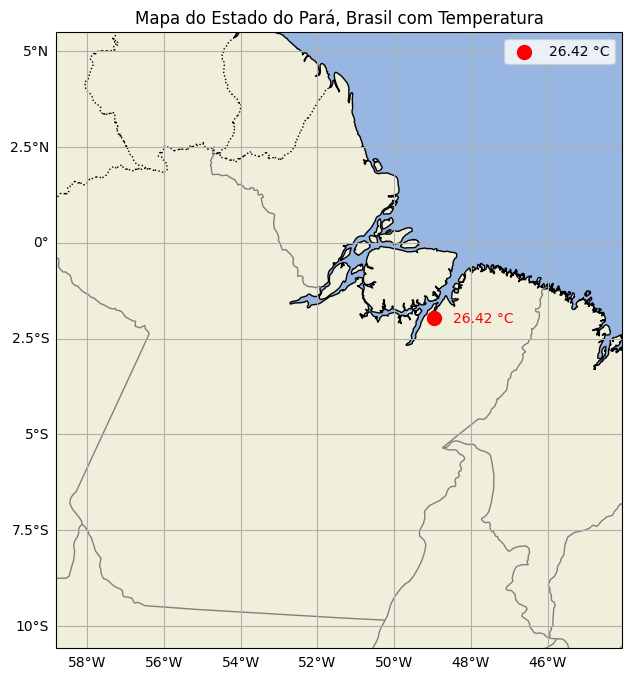

In [ ]:
!pip install cartopy
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature import NaturalEarthFeature

# Create figure
plt.figure(figsize=(10, 8))

# Map projection
ax = plt.axes(projection=ccrs.PlateCarree())

# Add basic map features
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Add Brazilian states (admin_1_states_provinces_lines for lines, admin_1_states_provinces for polygons)
states_provinces = NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='50m',
    facecolor='none',
    edgecolor='gray'
)
ax.add_feature(states_provinces)

# Define map extent for Pará, Brazil: [min_lon, max_lon, min_lat, max_lat]
# Approximate bounding box for Pará, with a small buffer
min_lon, max_lon = -57.81, -45.06
min_lat, max_lat = -9.57, 4.49
ax.set_extent([min_lon - 1, max_lon + 1, min_lat - 1, max_lat + 1], crs=ccrs.PlateCarree())

# Add the temperature data point
ax.scatter(target_lon, target_lat, color='red', marker='o', s=100, transform=ccrs.PlateCarree(), zorder=10, label=f'{temperature_celsius:.2f} °C')
ax.text(target_lon + 0.5, target_lat, f'{temperature_celsius:.2f} °C', transform=ccrs.PlateCarree(), color='red', fontsize=10, ha='left', va='center', zorder=11)

# Add gridlines
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Title and legend
plt.title("Mapa do Estado do Pará, Brasil com Temperatura")
plt.legend()

plt.show()